# Temp New (2026) Data Figures: Diurnal Ratio
Simple species-level comparison of paired night/day metabolic-rate ratios.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: include filtered=False rows if needed.
use_unfiltered = False

# Locate processed summary from common notebook working directories.
candidate_paths = [
    Path.cwd() / '../data/processed/batch_summary.csv',
    Path.cwd() / 'data/processed/batch_summary.csv',
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find data/processed/batch_summary.csv')

agg_df = pd.read_csv(data_path)
if 'messed_up' not in agg_df.columns:
    # Backward compatibility with summaries saved before quality labels were added.
    agg_df['messed_up'] = False
if 'issue_type' not in agg_df.columns:
    agg_df['issue_type'] = 'none'
agg_df['issue_type'] = agg_df['issue_type'].fillna('none').astype(str)
agg_df['messed_up'] = (
    agg_df['messed_up'].astype('string').str.lower()
    .map({'true': True, 'false': False, '1': True, '0': False})
    .fillna(False)
)
analysis_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

required_cols = {'trial', 'brick', 'channel', 'environment', 'RMR', 'species'}
missing = required_cols - set(analysis_df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

print(f'Loaded {len(agg_df)} total rows from {data_path}')
print(f'Rows in analysis set: {len(analysis_df)} (use_unfiltered={use_unfiltered})')

Loaded 133 total rows from /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv
Rows in analysis set: 113 (use_unfiltered=False)


In [3]:
# Load shared Figure style + palette (same pattern as Figure 2 notebook).
import importlib.util

style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

# Fallbacks keep this notebook robust if green tones are not defined in a style version.
LIGHT_GREEN = palette.get('light_green', '#cfe8d1')
DARK_GREEN = palette.get('dark_green', '#2d6a4f')

print(f'Shared style loaded from: {style_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle


In [4]:
# Build paired-trial table (Figure 1 pairs + tsujii + NOL), then compute ratio = night/day.
pair_trials = [
    ('trial4', 'trial4.5'),
    ('trial5', 'trial5.5'),
    ('trial6', 'trial6.5'),
    ('trial7', 'trial7.5'),
    ('trialtsu1', 'trialtsu1.5'),
    ('trialtsu2', 'trialtsu2.5'),
    ('trialnol1', 'trialnol1.5'),
    ('trialnol2', 'trialnol2.5'),
    ('trialnol4', 'trialnol4.5'),
    ('trialnol5', 'trialnol5.5'),  # Aug 27 day paired with Aug 26 night
]

paired_rows = []
for t_a, t_b in pair_trials:
    pair_df = analysis_df[analysis_df['trial'].isin([t_a, t_b])].copy()
    if pair_df.empty:
        continue

    for (brick, channel), grp in pair_df.groupby(['brick', 'channel']):
        if len(grp) != 2:
            continue

        envs = set(grp['environment'].astype(str))
        if envs != {'day', 'night'}:
            continue

        night_row = grp[grp['environment'] == 'night'].iloc[0]
        day_row = grp[grp['environment'] == 'day'].iloc[0]

        species_candidates = [night_row.get('species'), day_row.get('species')]
        species = next((s for s in species_candidates if pd.notna(s) and str(s).strip() != ''), 'unknown')

        day_rmr = float(day_row['RMR'])
        night_rmr = float(night_row['RMR'])
        if day_rmr <= 0:
            # Ratios are undefined/non-informative if day <= 0; skip those pairs.
            continue

        paired_rows.append({
            'pair': f'{t_a}_vs_{t_b}',
            'trial_night': t_a,
            'trial_day': t_b,
            'brick': brick,
            'channel': channel,
            'species': species,
            'night_RMR': night_rmr,
            'day_RMR': day_rmr,
            'night_day_ratio': night_rmr / day_rmr,
            'messed_up': bool(night_row.get('messed_up', False) or day_row.get('messed_up', False)),
            'issue_type': next((
                str(value) for value in [night_row.get('issue_type'), day_row.get('issue_type')]
                if pd.notna(value) and str(value) != 'none'
            ), 'none'),
        })

ratio_df = pd.DataFrame(paired_rows)
print(f'Paired rows retained for ratio: {len(ratio_df)}')
if not ratio_df.empty:
    print('Counts by species:')
    print(ratio_df['species'].value_counts())
display(ratio_df)

Paired rows retained for ratio: 40
Counts by species:
species
Photeros_NOL      20
Photeros_EGD      17
Vargula_tsujii     3
Name: count, dtype: int64


,pair,trial_night,trial_day,brick,channel,species,night_RMR,day_RMR,night_day_ratio,messed_up,issue_type
0,trial5_vs_trial5.5,trial5,trial5.5,box3,Ch2,Photeros_EGD,2.285837,2.245259,1.018073,False,none
1,trial5_vs_trial5.5,trial5,trial5.5,box3,Ch3,Photeros_EGD,0.920854,0.427888,2.152088,False,none
2,trial5_vs_trial5.5,trial5,trial5.5,box3,Ch4,Photeros_EGD,0.473624,0.706451,0.670427,False,none
3,trial5_vs_trial5.5,trial5,trial5.5,newbox,Ch2,Photeros_EGD,1.871534,0.756193,2.474942,False,none
4,trial5_vs_trial5.5,trial5,trial5.5,newbox,Ch3,Photeros_EGD,1.876437,1.199553,1.564280,False,none
5,trial5_vs_trial5.5,trial5,trial5.5,newbox,Ch4,Photeros_EGD,2.681803,2.995435,0.895297,False,none
6,trial6_vs_trial6.5,trial6,trial6.5,box3,Ch2,Photeros_EGD,1.954137,0.949858,2.057295,False,none
7,trial6_vs_trial6.5,trial6,trial6.5,box3,Ch4,Photeros_EGD,2.182509,0.679472,3.212065,False,none
8,trial6_vs_trial6.5,trial6,trial6.5,newbox,Ch2,Photeros_EGD,3.222056,1.841349,1.749835,False,none
9,trial6_vs_trial6.5,trial6,trial6.5,newbox,Ch3,Photeros_EGD,1.424907,0.920279,1.548341,False,none


Data points per species -> Photeros_EGD: n=17, Vargula_tsujii: n=3, Photeros_NOL: n=20


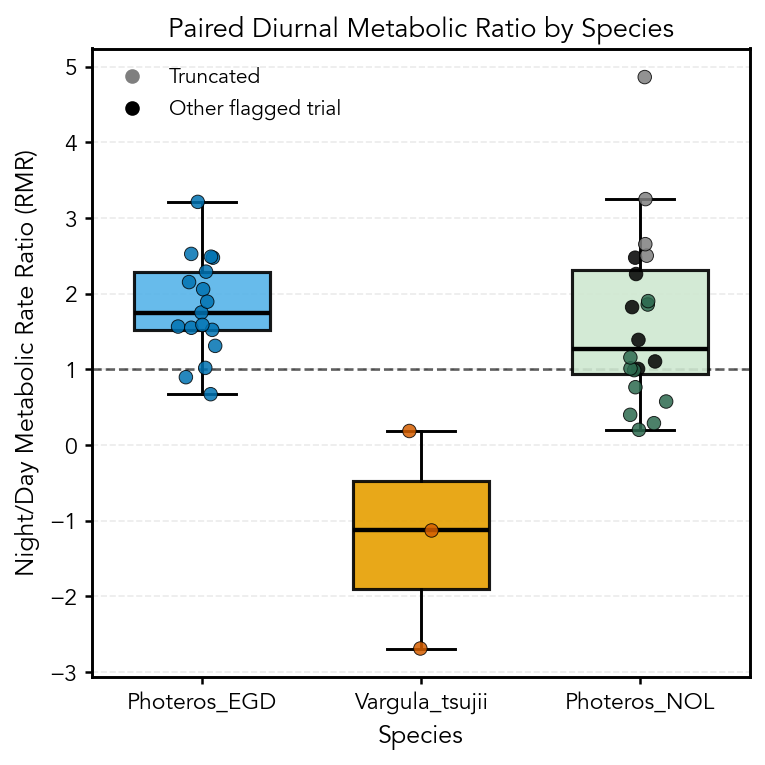

In [5]:
# Box-and-whisker + points: y-axis is night/day metabolic-rate ratio, grouped by species.
from matplotlib.lines import Line2D

if ratio_df.empty:
    print('No paired ratio data available to plot.')
else:
    species_order = ['Photeros_EGD', 'Vargula_tsujii', 'Photeros_NOL']
    available_species = [s for s in species_order if s in set(ratio_df['species'])]
    if not available_species:
        available_species = sorted(ratio_df['species'].dropna().unique())

    data_by_species = [
        ratio_df.loc[ratio_df['species'] == sp, 'night_day_ratio'].dropna().to_numpy()
        for sp in available_species
    ]

    x = np.arange(1, len(available_species) + 1)
    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    box_fill_colors = []
    point_colors = []
    for sp in available_species:
        if sp == 'Photeros_EGD':
            box_fill_colors.append(LIGHT_BLUE)
            point_colors.append(DARK_BLUE)
        elif sp == 'Vargula_tsujii':
            box_fill_colors.append(LIGHT_ORANGE)
            point_colors.append(DARK_ORANGE)
        elif sp == 'Photeros_NOL':
            box_fill_colors.append(LIGHT_GREEN)
            point_colors.append(DARK_GREEN)
        else:
            box_fill_colors.append('#b0b0b0')
            point_colors.append('#5a5a5a')

    bp = ax.boxplot(
        data_by_species,
        positions=x,
        widths=0.62,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=2.1, color='black'),
        boxprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.4, color='black'),
        capprops=dict(linewidth=1.4, color='black'),
    )

    for patch, face_color in zip(bp['boxes'], box_fill_colors):
        patch.set_facecolor(face_color)
        patch.set_alpha(0.9)

    rng = np.random.default_rng(42)
    for i, sp in enumerate(available_species):
        species_points = ratio_df.loc[ratio_df['species'] == sp].copy()
        if species_points.empty:
            continue
        jitter = rng.normal(0, 0.055, size=len(species_points))
        point_facecolors = np.select(
            [
                species_points['issue_type'].eq('computer_shutdown').to_numpy(),
                species_points['messed_up'].to_numpy(),
            ],
            ['#7f7f7f', 'black'],
            default=point_colors[i],
        )
        ax.scatter(
            np.full(len(species_points), x[i]) + jitter,
            species_points['night_day_ratio'].to_numpy(),
            s=42,
            alpha=0.85,
            color=point_facecolors,
            edgecolors='black',
            linewidths=0.45,
            zorder=3,
        )

    label_map = {
        'Photeros_EGD': 'Photeros_EGD',
        'Vargula_tsujii': 'Vargula_tsujii',
        'Photeros_NOL': 'Photeros_NOL',
    }

    ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels([label_map.get(s, s) for s in available_species], rotation=0)
    ax.set_ylabel('Night/Day Metabolic Rate Ratio (RMR)')
    ax.set_xlabel('Species')
    ax.set_title('Paired Diurnal Metabolic Ratio by Species')
    ax.grid(axis='y', linestyle='--', alpha=0.25, zorder=0)
    quality_handles = []
    if ratio_df['issue_type'].eq('computer_shutdown').any():
        quality_handles.append(Line2D([0], [0], marker='o', linestyle='none', color='#7f7f7f', label='Truncated'))
    if (ratio_df['messed_up'] & ~ratio_df['issue_type'].eq('computer_shutdown')).any():
        quality_handles.append(Line2D([0], [0], marker='o', linestyle='none', color='black', label='Other flagged trial'))
    if quality_handles:
        ax.legend(handles=quality_handles, frameon=False, loc='best')

    counts_txt = ', '.join([f"{sp}: n={int((ratio_df['species'] == sp).sum())}" for sp in available_species])
    print('Data points per species -> ' + counts_txt)

    plt.tight_layout()
    plt.show()

Slopegraph rows plotted: 40


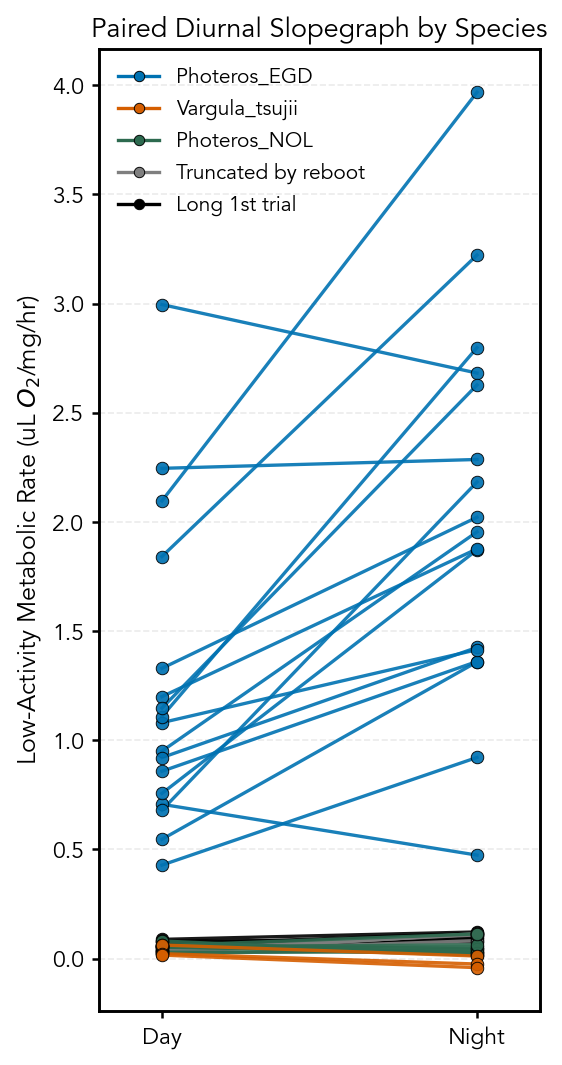

In [43]:
# Slopegraph: absolute day vs night RMR for all paired rows, colored by species.
from matplotlib.lines import Line2D

if ratio_df.empty:
    print('No paired ratio data available to plot.')
else:
    slope_df = ratio_df.copy()
    slope_df = slope_df.sort_values(['species', 'pair', 'brick', 'channel']).reset_index(drop=True)

    # Dynamic height keeps rows legible if more paired points are added.
    fig_slope, ax_slope = plt.subplots(figsize=(3.8, max(4.8, 0.18 * len(slope_df))))
    x_day, x_night = 0, 1

    species_colors = {
        'Photeros_EGD': DARK_BLUE,
        'Vargula_tsujii': DARK_ORANGE,
        'Photeros_NOL': DARK_GREEN,
    }

    for _, row in slope_df.iterrows():
        species = str(row['species'])
        if row.get('issue_type') == 'computer_shutdown':
            color = '#7f7f7f'
        elif bool(row.get('messed_up', False)):
            color = 'black'
        else:
            color = species_colors.get(species, '#5a5a5a')

        ax_slope.plot(
            [x_day, x_night],
            [row['day_RMR'], row['night_RMR']],
            color=color,
            linewidth=1.6,
            alpha=0.9,
            zorder=2,
        )
        ax_slope.scatter(
            [x_day, x_night],
            [row['day_RMR'], row['night_RMR']],
            color=color,
            edgecolors='black',
            linewidths=0.45,
            s=36,
            alpha=0.92,
            zorder=3,
        )

    ax_slope.set_xlim(-0.2, 1.2)
    ax_slope.set_xticks([x_day, x_night])
    ax_slope.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax_slope.set_ylabel('Low-Activity Metabolic Rate (uL $O_2$/mg/hr)')
    ax_slope.set_title('Paired Diurnal Slopegraph by Species')
    ax_slope.grid(axis='y', linestyle='--', alpha=0.25)

    species_present = [
        sp for sp in ['Photeros_EGD', 'Vargula_tsujii', 'Photeros_NOL']
        if sp in set(slope_df['species'])
    ]

    legend_handles = [
        Line2D([0], [0], color=species_colors[sp], marker='o', lw=1.6, markersize=5,
               markeredgecolor='black', markeredgewidth=0.45, label=sp)
        for sp in species_present
    ]
    if slope_df['issue_type'].eq('computer_shutdown').any():
        legend_handles.append(
            Line2D([0], [0], color='#7f7f7f', marker='o', lw=1.6, markersize=5,
                   markeredgecolor='black', markeredgewidth=0.45, label='Truncated by reboot')
        )
    if (slope_df['messed_up'] & ~slope_df['issue_type'].eq('computer_shutdown')).any():
        legend_handles.append(
            Line2D([0], [0], color='black', marker='o', lw=1.6, markersize=5,
                   markeredgecolor='black', markeredgewidth=0.45, label='Long 1st trial')
        )

    if legend_handles:
        ax_slope.legend(handles=legend_handles, frameon=False, loc='best')

    print(f'Slopegraph rows plotted: {len(slope_df)}')
    plt.tight_layout()
    plt.show()

In [44]:
# Optional save.
figures_dir = Path.cwd() / '../figures'
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    out_pdf = (figures_dir / 'TempTsujii_Figure_diurnal.pdf').resolve()
    fig.savefig(out_pdf, bbox_inches='tight')
    print(f'Saved PDF: {out_pdf}')
else:
    print('No figure found. Run plotting cell first.')

Saved PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/TempTsujii_Figure_diurnal.pdf


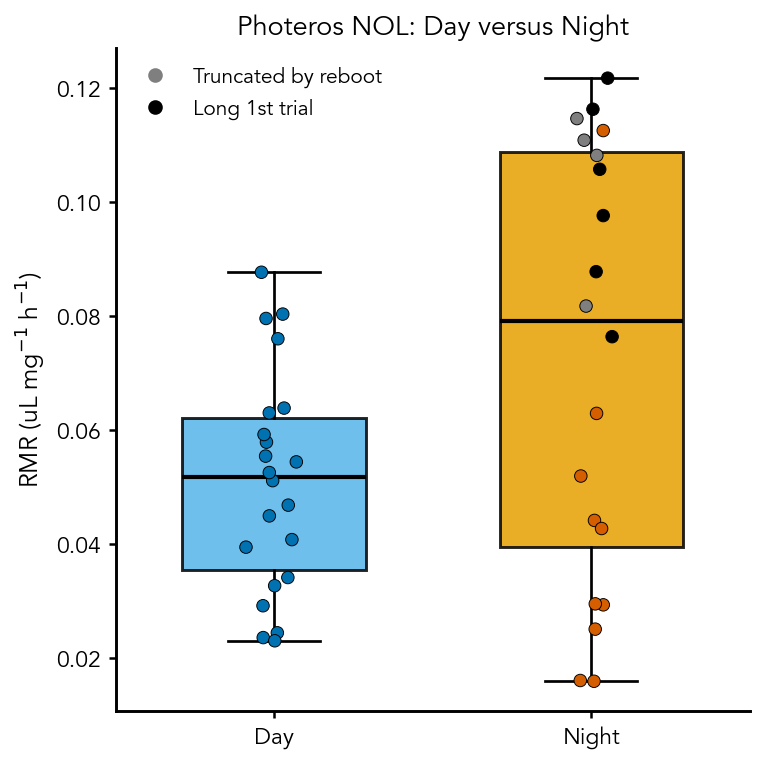

In [45]:
# NOL-only day versus night RMR: box-and-whisker plot with individual points.
from matplotlib.lines import Line2D

nol_df = analysis_df[
    (analysis_df['species'] == 'Photeros_NOL') &
    (analysis_df['environment'].isin(['day', 'night']))
].copy()

if nol_df.empty:
    print('No NOL day/night data available to plot.')
else:
    environment_order = ['day', 'night']
    data_by_environment = [
        nol_df.loc[nol_df['environment'] == environment, 'RMR'].dropna().to_numpy()
        for environment in environment_order
    ]

    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    box = ax.boxplot(
        data_by_environment,
        positions=[1, 2],
        widths=0.58,
        patch_artist=True,
        showfliers=False,
        medianprops={'linewidth': 2, 'color': 'black'},
        boxprops={'linewidth': 1.4, 'color': 'black'},
        whiskerprops={'linewidth': 1.3, 'color': 'black'},
        capprops={'linewidth': 1.3, 'color': 'black'},
    )
    for patch, color in zip(box['boxes'], [LIGHT_BLUE, LIGHT_ORANGE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)

    for position, environment in enumerate(environment_order, start=1):
        environment_points = nol_df.loc[
            nol_df['environment'] == environment, ['RMR', 'messed_up', 'issue_type']
        ].dropna(subset=['RMR'])
        values = environment_points['RMR'].to_numpy()
        jitter = np.random.default_rng(42 + position).normal(position, 0.045, len(values))
        clean_color = [DARK_BLUE, DARK_ORANGE][position - 1]
        point_facecolors = np.select(
            [
                environment_points['issue_type'].eq('computer_shutdown').to_numpy(),
                environment_points['messed_up'].to_numpy(),
            ],
            ['#7f7f7f', 'black'],
            default=clean_color,
        )
        ax.scatter(jitter, values, color=point_facecolors, edgecolors='black', linewidths=0.45, zorder=3)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Day', 'Night'])
    ax.set_ylabel('RMR (uL mg$^{-1}$ h$^{-1}$)')
    ax.set_title('Photeros NOL: Day versus Night')
    quality_handles = []
    if nol_df['issue_type'].eq('computer_shutdown').any():
        quality_handles.append(Line2D([0], [0], marker='o', linestyle='none', color='#7f7f7f', label='Truncated by reboot'))
    if (nol_df['messed_up'] & ~nol_df['issue_type'].eq('computer_shutdown')).any():
        quality_handles.append(Line2D([0], [0], marker='o', linestyle='none', color='black', label='Long 1st trial'))
    if quality_handles:
        ax.legend(handles=quality_handles, frameon=False, loc='best')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    plt.show()

In [46]:
# Paired statistical test for NOL day versus night RMR.
# The unpaired trialnol3 nighttime data are excluded from this test.
from scipy.stats import wilcoxon

nol_paired_ratio_df = ratio_df[
    ratio_df['species'].eq('Photeros_NOL')
].dropna(subset=['day_RMR', 'night_RMR']).copy()

if len(nol_paired_ratio_df) < 2:
    print('At least two paired NOL observations are required for the Wilcoxon test.')
else:
    wilcoxon_result = wilcoxon(
        nol_paired_ratio_df['day_RMR'],
        nol_paired_ratio_df['night_RMR'],
        alternative='two-sided',
    )
    print('NOL paired day versus night RMR Wilcoxon signed-rank test')
    print(f"Paired observations: {len(nol_paired_ratio_df)}")
    print(f"Statistic: {wilcoxon_result.statistic:.4g}")
    print(f"p-value: {wilcoxon_result.pvalue:.4g}")

NOL paired day versus night RMR Wilcoxon signed-rank test
Paired observations: 20
Statistic: 55
p-value: 0.06372


## Clean companion plots

These repeat the quality-coded plots without visually separating retained flagged observations. Rows with `filtered=False` remain excluded, but all retained NOL observations use the standard NOL or day/night colors.

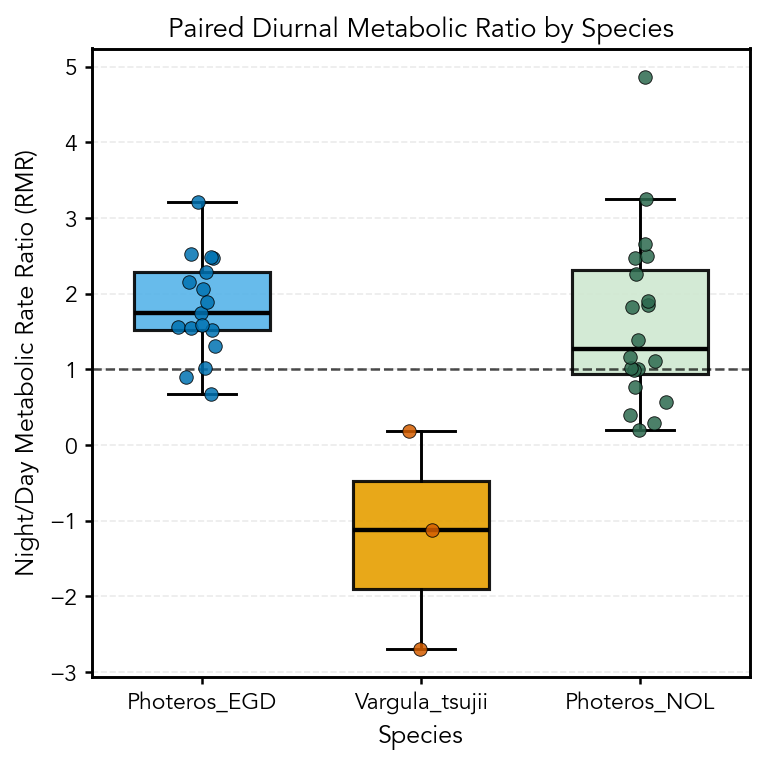

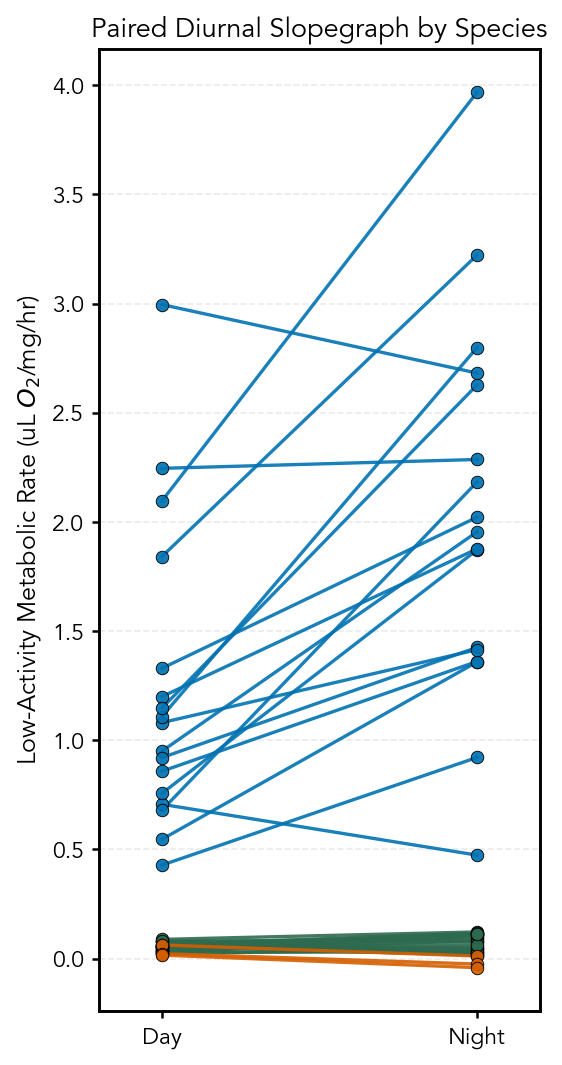

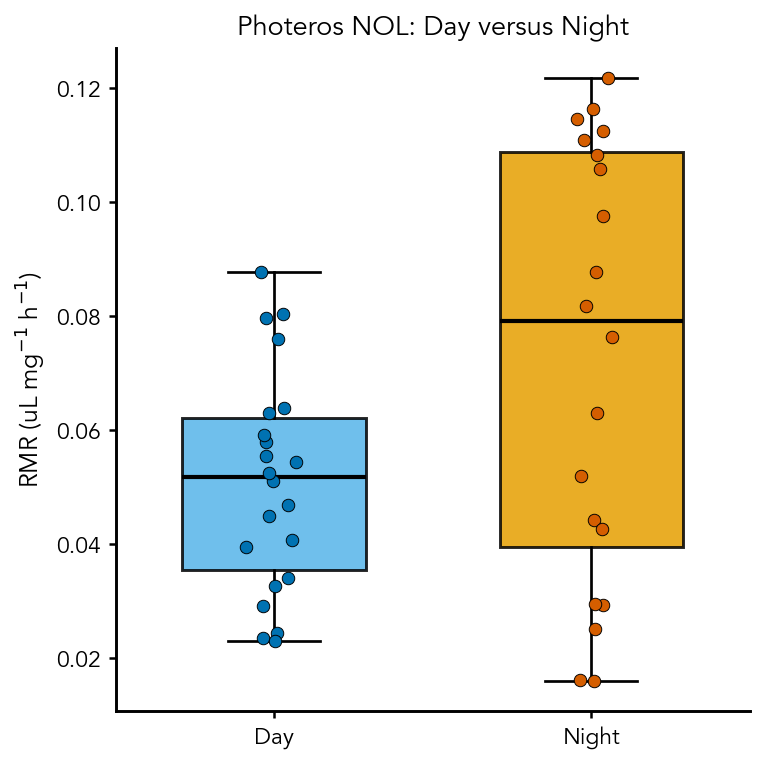

In [47]:
# Clean versions of the ratio, slopegraph, and NOL day/night plots.
# Quality labels remain in the data but do not affect point or line colors here.

# 1. Night/day ratio by species
if ratio_df.empty:
    print('No paired ratio data available for the clean ratio plot.')
else:
    clean_species_order = [
        species for species in ['Photeros_EGD', 'Vargula_tsujii', 'Photeros_NOL']
        if species in set(ratio_df['species'])
    ]
    clean_ratio_values = [
        ratio_df.loc[ratio_df['species'] == species, 'night_day_ratio'].dropna().to_numpy()
        for species in clean_species_order
    ]
    clean_box_colors = {'Photeros_EGD': LIGHT_BLUE, 'Vargula_tsujii': LIGHT_ORANGE, 'Photeros_NOL': LIGHT_GREEN}
    clean_point_colors = {'Photeros_EGD': DARK_BLUE, 'Vargula_tsujii': DARK_ORANGE, 'Photeros_NOL': DARK_GREEN}
    clean_x = np.arange(1, len(clean_species_order) + 1)
    fig_clean_ratio, ax_clean_ratio = plt.subplots(figsize=(5.2, 5.2))
    clean_bp = ax_clean_ratio.boxplot(
        clean_ratio_values, positions=clean_x, widths=0.62, patch_artist=True, showfliers=False,
        medianprops=dict(linewidth=2.1, color='black'), boxprops=dict(linewidth=1.5, color='black'),
        whiskerprops=dict(linewidth=1.4, color='black'), capprops=dict(linewidth=1.4, color='black'),
    )
    for patch, species in zip(clean_bp['boxes'], clean_species_order):
        patch.set_facecolor(clean_box_colors.get(species, '#b0b0b0'))
        patch.set_alpha(0.9)
    clean_rng = np.random.default_rng(42)
    for position, species, values in zip(clean_x, clean_species_order, clean_ratio_values):
        jitter = clean_rng.normal(position, 0.055, len(values))
        ax_clean_ratio.scatter(jitter, values, s=42, alpha=0.85, color=clean_point_colors.get(species, '#5a5a5a'), edgecolors='black', linewidths=0.45, zorder=3)
    ax_clean_ratio.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax_clean_ratio.set_xticks(clean_x)
    ax_clean_ratio.set_xticklabels(clean_species_order)
    ax_clean_ratio.set_ylabel('Night/Day Metabolic Rate Ratio (RMR)')
    ax_clean_ratio.set_xlabel('Species')
    ax_clean_ratio.set_title('Paired Diurnal Metabolic Ratio by Species')
    ax_clean_ratio.grid(axis='y', linestyle='--', alpha=0.25)
    fig_clean_ratio.tight_layout()
    plt.show()

# 2. Clean paired day/night slopegraph
if not ratio_df.empty:
    clean_slope_df = ratio_df.sort_values(['species', 'pair', 'brick', 'channel']).reset_index(drop=True)
    fig_clean_slope, ax_clean_slope = plt.subplots(figsize=(3.8, max(4.8, 0.18 * len(clean_slope_df))))
    clean_species_colors = {'Photeros_EGD': DARK_BLUE, 'Vargula_tsujii': DARK_ORANGE, 'Photeros_NOL': DARK_GREEN}
    for _, row in clean_slope_df.iterrows():
        color = clean_species_colors.get(str(row['species']), '#5a5a5a')
        ax_clean_slope.plot([0, 1], [row['day_RMR'], row['night_RMR']], color=color, linewidth=1.6, alpha=0.9)
        ax_clean_slope.scatter([0, 1], [row['day_RMR'], row['night_RMR']], color=color, edgecolors='black', linewidths=0.45, s=36, alpha=0.92, zorder=3)
    ax_clean_slope.set_xlim(-0.2, 1.2)
    ax_clean_slope.set_xticks([0, 1])
    ax_clean_slope.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax_clean_slope.set_ylabel('Low-Activity Metabolic Rate (uL $O_2$/mg/hr)')
    ax_clean_slope.set_title('Paired Diurnal Slopegraph by Species')
    ax_clean_slope.grid(axis='y', linestyle='--', alpha=0.25)
    fig_clean_slope.tight_layout()
    plt.show()

# 3. Clean NOL-only day versus night plot
if nol_df.empty:
    print('No NOL day/night data available for the clean plot.')
else:
    clean_environment_order = ['day', 'night']
    clean_nol_values = [nol_df.loc[nol_df['environment'] == environment, 'RMR'].dropna().to_numpy() for environment in clean_environment_order]
    fig_clean_nol, ax_clean_nol = plt.subplots(figsize=(5.2, 5.2))
    clean_nol_box = ax_clean_nol.boxplot(
        clean_nol_values, positions=[1, 2], widths=0.58, patch_artist=True, showfliers=False,
        medianprops={'linewidth': 2, 'color': 'black'}, boxprops={'linewidth': 1.4, 'color': 'black'},
        whiskerprops={'linewidth': 1.3, 'color': 'black'}, capprops={'linewidth': 1.3, 'color': 'black'},
    )
    for patch, color in zip(clean_nol_box['boxes'], [LIGHT_BLUE, LIGHT_ORANGE]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for position, (environment, values) in enumerate(zip(clean_environment_order, clean_nol_values), start=1):
        jitter = np.random.default_rng(42 + position).normal(position, 0.045, len(values))
        ax_clean_nol.scatter(jitter, values, color=[DARK_BLUE, DARK_ORANGE][position - 1], edgecolors='black', linewidths=0.45, zorder=3)
    ax_clean_nol.set_xticks([1, 2])
    ax_clean_nol.set_xticklabels(['Day', 'Night'])
    ax_clean_nol.set_ylabel('RMR (uL mg$^{-1}$ h$^{-1}$)')
    ax_clean_nol.set_title('Photeros NOL: Day versus Night')
    ax_clean_nol.spines['top'].set_visible(False)
    ax_clean_nol.spines['right'].set_visible(False)
    fig_clean_nol.tight_layout()
    plt.show()

NOL slopegraph rows plotted: 20


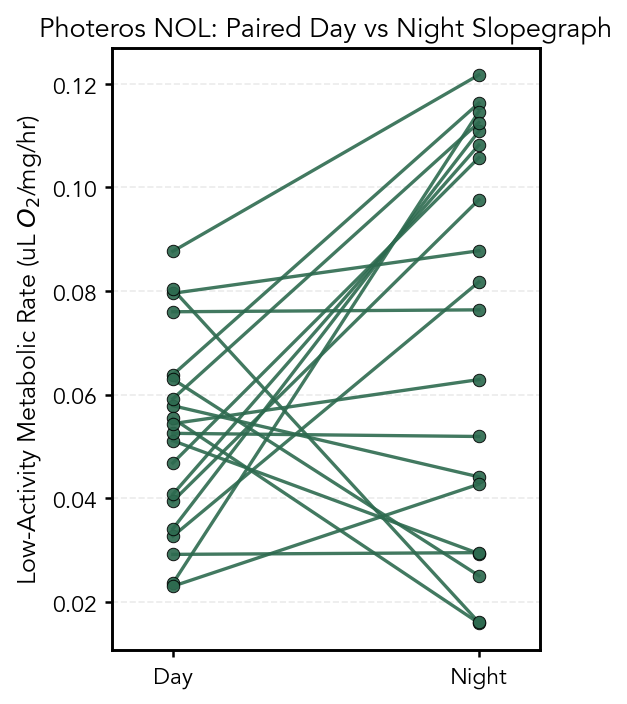

In [7]:
# NOL-only paired slopegraph for day versus night RMR.

nol_slope_df = ratio_df[ratio_df['species'].eq('Photeros_NOL')].copy()

if nol_slope_df.empty:
    print('No NOL paired ratio data available for the slopegraph.')
else:
    nol_slope_df = nol_slope_df.sort_values(['pair', 'brick', 'channel']).reset_index(drop=True)
    fig_nol_slope, ax_nol_slope = plt.subplots(figsize=(3.8, max(4.8, 0.18 * len(nol_slope_df))))

    for _, row in nol_slope_df.iterrows():
        color = DARK_GREEN

        ax_nol_slope.plot(
            [0, 1],
            [row['day_RMR'], row['night_RMR']],
            color=color,
            linewidth=1.6,
            alpha=0.9,
            zorder=2,
        )
        ax_nol_slope.scatter(
            [0, 1],
            [row['day_RMR'], row['night_RMR']],
            color=color,
            edgecolors='black',
            linewidths=0.45,
            s=36,
            alpha=0.92,
            zorder=3,
        )

    ax_nol_slope.set_xlim(-0.2, 1.2)
    ax_nol_slope.set_xticks([0, 1])
    ax_nol_slope.set_xticklabels(['Day', 'Night'], fontsize=11, fontweight='bold')
    ax_nol_slope.set_ylabel('Low-Activity Metabolic Rate (uL $O_2$/mg/hr)')
    ax_nol_slope.set_title('Photeros NOL: Paired Day vs Night Slopegraph')
    ax_nol_slope.grid(axis='y', linestyle='--', alpha=0.25)

    print(f'NOL slopegraph rows plotted: {len(nol_slope_df)}')
    fig_nol_slope.tight_layout()
    plt.show()


In [8]:
# Exact binomial test: are more NOL paired trials higher at night than day?
from scipy import stats

nol_binom_df = ratio_df[
    ratio_df['species'].eq('Photeros_NOL')
].dropna(subset=['day_RMR', 'night_RMR']).copy()

if len(nol_binom_df) == 0:
    print('No NOL paired observations available for the binomial test.')
else:
    night_gt_day = (nol_binom_df['night_RMR'] > nol_binom_df['day_RMR']).astype(int)
    k = int(night_gt_day.sum())
    n = len(night_gt_day)

    print(f'NOL paired trials: n={n}')
    print(f'Night > day: k={k}')
    print(f'Proportion greater at night: {k / n:.3f}')

    binom_test = stats.binomtest(k=k, n=n, p=0.5, alternative='greater')
    print('Exact binomial test against p = 0.5 (one-sided, H1: p > 0.5)')
    print(f'P-value: {binom_test.pvalue:.4g}')
    print(f'95% CI for p: {binom_test.proportion_ci(confidence_level=0.95, method="exact")}')


NOL paired trials: n=20
Night > day: k=14
Proportion greater at night: 0.700
Exact binomial test against p = 0.5 (one-sided, H1: p > 0.5)
P-value: 0.05766
95% CI for p: ConfidenceInterval(low=0.49218159338518497, high=1.0)
